In [1]:
# Single-row floe properties with the seasonal evolution of FSD and FSD slope

In [1]:
import os
import pandas as pd
import ultraplot as pplt
import numpy as np

# Load floe data
floe_lib_clean = {}
for file in os.listdir('../data/floe_tracker/ift_floe_property_tables/with_nsidc/'):
    if 'csv' in file: 
        year = int(file.replace('.csv', '').split('_')[-1])
        floe_lib_clean[year] = pd.read_csv('../data/floe_tracker/ift_floe_property_tables/with_nsidc/' + file,
                                         index_col=0, dtype={'classification': str})
        floe_lib_clean[year]['datetime'] = pd.to_datetime(floe_lib_clean[year]['datetime'])

df = pd.concat(floe_lib_clean).reset_index()
df = df.loc[(df.datetime.dt.dayofyear >= 91) & (df.datetime.dt.dayofyear <= 258)]
df['perim_km'] = df.perimeter*.25
df['area_km'] = df.area*.25*.25
df['area_adj_km'] = (np.sqrt(df.area) + 8)**2*.25*.25 # Pixel shift minimizes error against manual
df['doy'] = df.datetime.dt.dayofyear
df['year'] = df.datetime.dt.year


df['band_1_reflectance'] = df['tc_channel0']/255
df['month'] = df.datetime.dt.month
df['n'] = df.groupby('datetime').transform(lambda x: len(x))['area']
df['length_scale_km'] = df['area_adj_km']**0.5


In [2]:
### Load FSD data
results = []
for year in range(2003, 2021):
    results.append(pd.read_csv('../data/floe_tracker/ift_fsd_tables/ift_fsd_table_{y}.csv'.format(y=year), parse_dates=['date']))
results = pd.concat(results, axis=0)
results_alt = pd.read_csv('../data/floe_tracker/ift_fsd_tables/ift_fsd_table_all_years_by_DOY.csv')
dr = pd.date_range('2020-04-01', '2020-09-01', freq='1MS')
dr_doy = results.groupby('month').mean()['doy']


In [3]:
# Panel 1: Add floe count per image by day of year
# Consider separating the shape, reflectance data
# Consider adding the sea ice extent as an overlay to the ice concentration
count_range = df.groupby(['year', 'doy']).count().pivot_table(
                index='year', columns='doy', values='area').quantile(
                    [0.1, 0.25, 0.5, 0.75, 0.9], axis=0).T
count_range.columns = ['p10', 'p25', 'med', 'p75', 'p90']
count_range

,p10,p25,med,p75,p90
doy,,,,,
91,201.4,292.00,513.0,673.00,737.8
92,200.3,325.75,465.5,617.00,690.0
93,229.2,320.00,392.0,651.00,714.6
94,167.5,261.00,392.0,618.00,714.4
95,107.4,278.00,452.0,622.00,767.2
...,...,...,...,...,...
254,21.8,30.00,39.0,86.50,154.0
255,14.0,21.00,47.0,123.50,156.4
256,11.7,52.50,69.0,124.00,151.8


In [33]:
# Select a sample of dates to plot by selecting 
# a date from each month and year at random, conditioned on at least
# 200 floes being present.

counts_by_date = df.groupby('datetime').count()['floe_id']
counts_by_date = pd.DataFrame({'year': counts_by_date.index.year,
              'month': counts_by_date.index.month,
              'datetime': counts_by_date.index,
              'n': counts_by_date.values})
counts_by_date = counts_by_date.loc[counts_by_date['n'] > 200, :]
plot_samples = counts_by_date.groupby(['year', 'month']).sample(random_state=150)
plot_doys = plot_samples.datetime.dt.dayofyear.unique()
counts_by_date['n'] = counts_by_date['n'].rolling(5, center=True, min_periods=0).median()
plot_doys.sort()

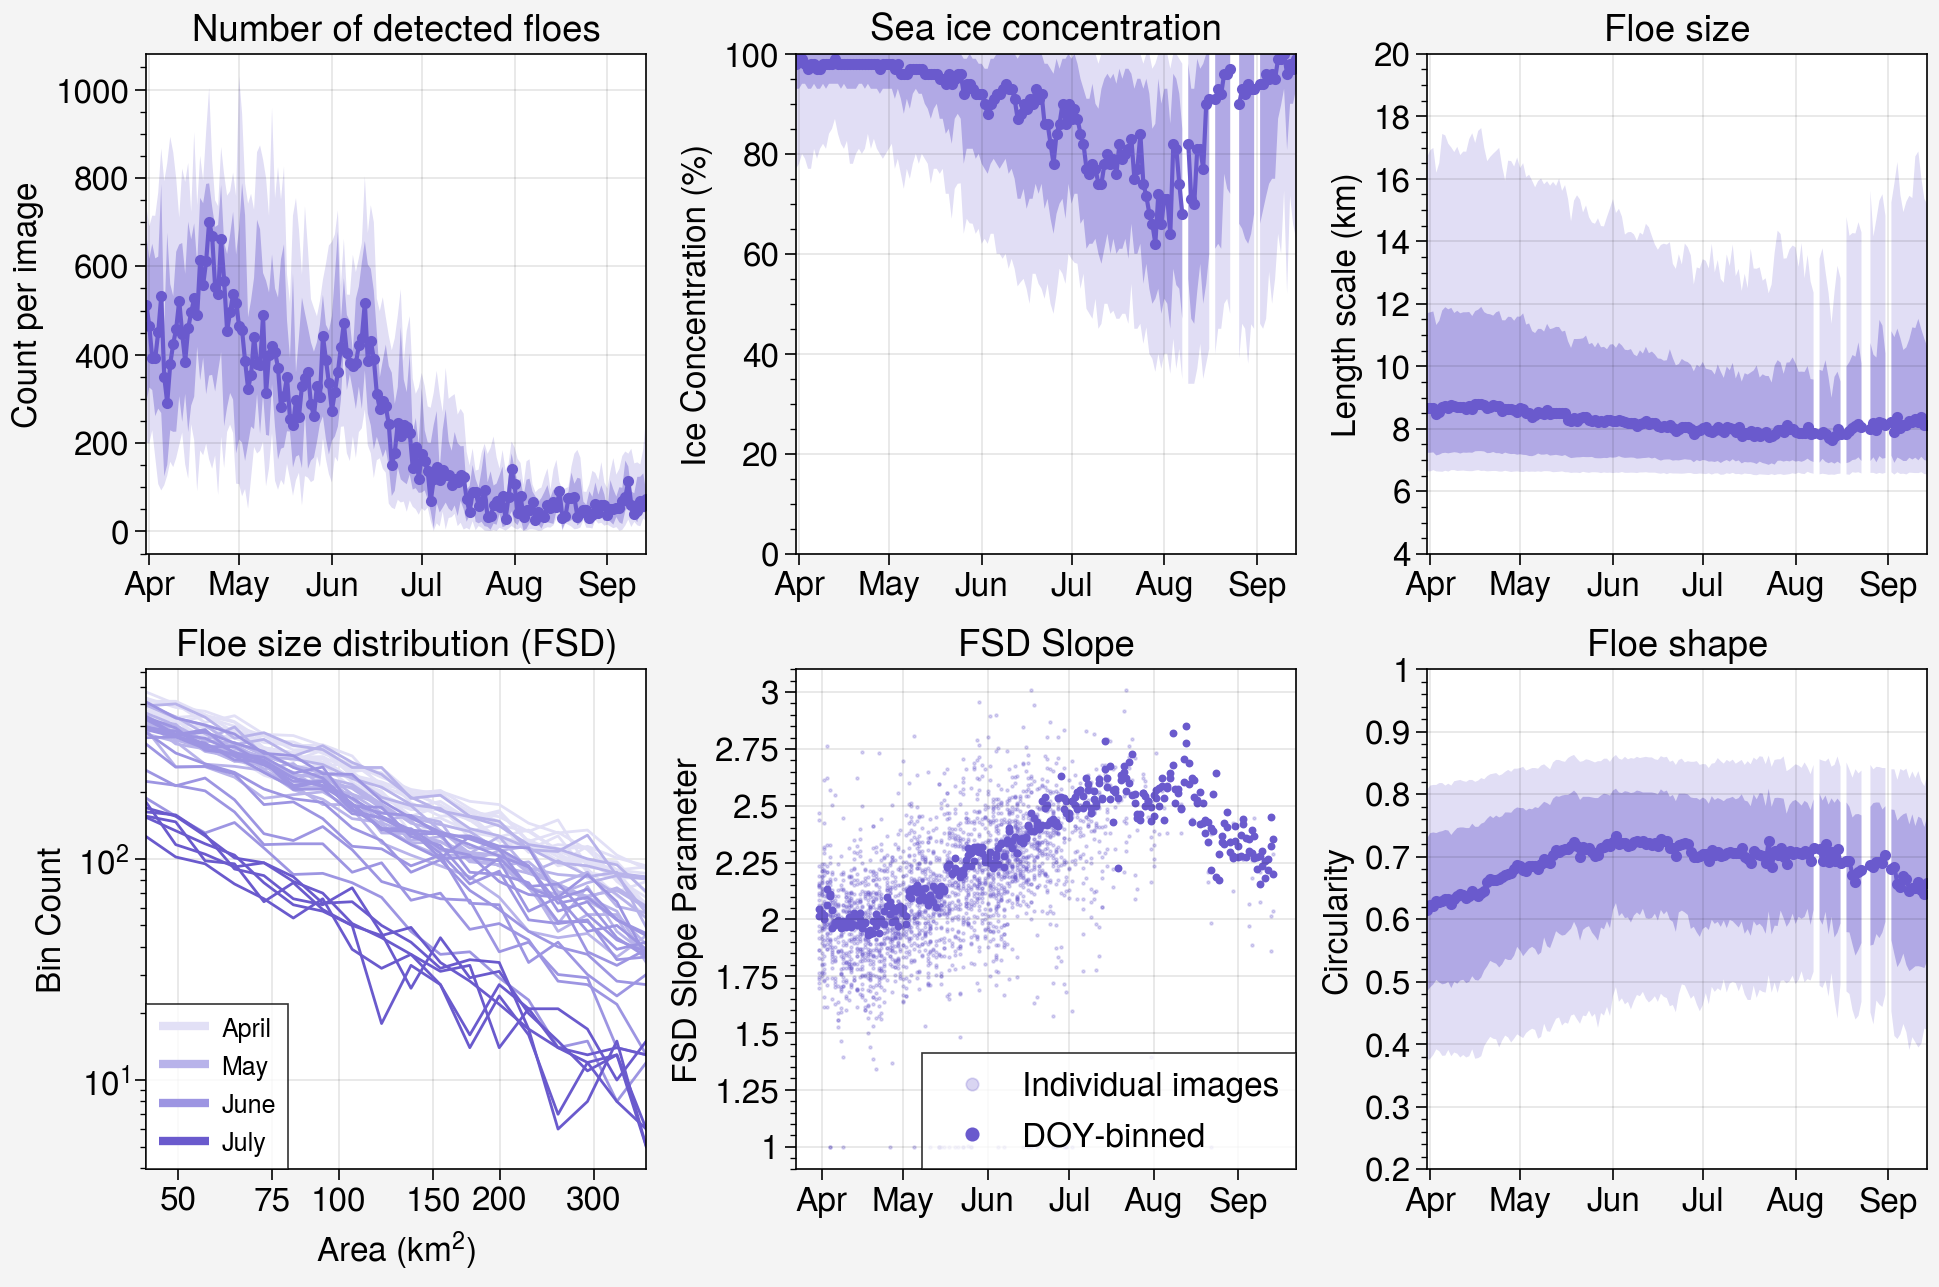

In [34]:
df['sea_ice_concentration'] = 100 * df['nsidc_sic']

fig, axs = pplt.subplots(ncols=3, share=False, nrows=2)

idx = df.n > 30
# idx = idx & df.nsidc_sic.between(0.15, 0.85)
idx = idx & df.final_classification

# Plot floe count
# 'circularity', 'band_1_reflectance', 
ax = axs[0]
ax.plot(count_range['med'], 
            fadedata=[count_range['p90'],
                      count_range['p10']],
            shadedata=[count_range['p75'],
                      count_range['p25']],
            marker='.', color='slateblue')
ax.format(ylabel='Floe Count',
          xlocator=dr.dayofyear,
          xformatter=[d.strftime('%b') for d in dr],
          xlabel='', fontsize=12)


ylims = {'sea_ice_concentration': (0, 100),
         'length_scale_km': (4, 20), 
         'circularity': (0.2, 1),
         'band_1_reflectance': (0.5, 1),
         'alpha_tpl': (0.9, 3.1)}

for col, var in zip([1, 2, 5],
                          ['sea_ice_concentration', 'length_scale_km', 'circularity']):
    # shade data
    ax = axs[col]
    n = df.loc[idx, [var, 'doy']].groupby('doy').count()
    med = df.loc[idx, [var, 'doy']].groupby('doy').median().where(n > 500)
    p90 = df.loc[idx, [var, 'doy']].groupby('doy').quantile(0.90).where(n > 500)
    p10 = df.loc[idx, [var, 'doy']].groupby('doy').quantile(0.10).where(n > 500)
    p75 = df.loc[idx, [var, 'doy']].groupby('doy').quantile(0.75).where(n > 500)
    p25 = df.loc[idx, [var, 'doy']].groupby('doy').quantile(0.25).where(n > 500)
    ax.plot(med[var], fadedata=[p90[var], p10[var]],
            shadedata=[p75[var], p25[var]], marker='.', color='slateblue')
    ax.format(ylabel=var.replace('_', ' '),
              xlocator=dr.dayofyear,
              xformatter=[d.strftime('%b') for d in dr],
              xlabel='', fontsize=12, ylim=ylims[var])


ax = axs[3]
slate_colors = [c['color'] for c in pplt.Cycle('slateblue', 10)]
colors = {month: color for month, color in zip([4, 5, 6, 7],
                                               [slate_colors[0], slate_colors[3], slate_colors[5],
                                                'slateblue'])}
bins = np.logspace(np.log10(36), np.log10(400), 20)
bin_centers = 0.5 * (bins[0:-1] + bins[1:])

for day_of_year in plot_doys:
    data = df.loc[df.datetime.dt.dayofyear == day_of_year, :]
    month = data.datetime.dt.month.values[0]
    x, y = np.histogram(data['area_km'], bins=bins, density=False)
    ax.plot(bin_centers[1:], x[1:], marker='', c=colors[month], lw=1)
    ax.format(yscale='log', xscale='log', xlocator=[50, 75, 100, 150, 200, 300],
              xminorticks='none', yformatter='log', fontsize=12,
              ylabel='Bin Count', xlabel='Area (km$^2$)', title='Floe size distribution (FSD)')


h = [ax.plot([],[], lw=3, ls='-', color=colors[m]) for m in [4, 5, 6, 7]]
ax.legend(h, ['April', 'May', 'June', 'July'], ncols=1, loc='ll')



ax = axs[4]
n_threshold = 1 # check what this one is doing -- is it just to see if the month has anything in it?
month_threshold = 300
var = 'alpha_tpl'
time_idx = (results.month != 3) & (results.month <= 9)
df_pivot = results.loc[time_idx & (results.n > n_threshold)].pivot_table(
    index='date', values=var, columns='month')
df_pivot = df_pivot.rolling(15, center=True, min_periods=0).median()
month_counts = df_pivot.notnull().sum() 
month_idx = [m for m in month_counts.index if month_counts[m] > month_threshold]
_ = ax.scatter(results.loc[results.n > n_threshold].date.dt.dayofyear,
               results.loc[results.n > n_threshold, var],
               marker='o', ms=1, zorder=0,
               label='Individual images', color='slateblue', alpha=0.25)
_ = ax.scatter(results_alt.doy, results_alt[var],
               marker='o', ms=5, zorder=0,
               color='slateblue', label='DOY-binned')
ax.legend(loc='lr', ncols=1, ms=20, fontsize=12)
ax.format(title='FSD Slope Parameter', ylabel='Truncated Power Law $\\alpha$',
         xlocator=dr.dayofyear, xformatter=[d.strftime('%b') for d in dr],
         xlabel='', fontsize=12, ylim=ylims[var])
    
axs[0].format(ylabel='Count per image', title='Number of detected floes')
axs[1].format(ylabel='Ice Concentration (%)', title='Sea ice concentration')
axs[2].format(ylabel='Length scale (km)', title='Floe size')
axs[5].format(ylabel='Circularity', title='Floe shape')
axs[4].format(ylabel='FSD Slope Parameter', title='FSD Slope')

# axs[1].format(ylabel='Circularity', title='Floe Shape')
# axs[2].format(ylabel='Band 1 Reflectance', title='Floe Reflectance')
fig.save('../figures/presentations/floe_properties_osm.png', dpi=300)
fig.save('../figures/presentations/floe_properties_osm.pdf', dpi=300)

In [93]:
### SIMPLER VERSION ###

df['sea_ice_concentration'] = 100 * df['nsidc_sic']

fig, axs = pplt.subplots(ncols=4, share=False, nrows=1)

idx = df.n > 30
# idx = idx & df.nsidc_sic.between(0.15, 0.85)
idx = idx & df.final_classification

# Plot floe count
# 'circularity', 'band_1_reflectance', 
ax = axs[0]
ax.plot(count_range['med'], 
            fadedata=[count_range['p90'],
                      count_range['p10']],
            shadedata=[count_range['p75'],
                      count_range['p25']],
            marker='.', color='slateblue')

# Consider overlaying the climatological sea ice extent
# Add suptitle with Climatology 2003-2020 to remind audience
ax.format(ylabel='Floe Count',
          xlocator=dr.dayofyear,
          xformatter=[d.strftime('%b') for d in dr],
          xlabel='', fontsize=12)

ylims = {'sea_ice_concentration': (0, 100),
         'length_scale_km': (4, 20), 
         'circularity': (0.2, 1),
         'band_1_reflectance': (0.5, 1),
         'alpha_tpl': (0.9, 3.1)}

for col, var in zip([1], ['length_scale_km']):
    # shade data
    ax = axs[col]
    n = df.loc[idx, [var, 'doy']].groupby('doy').count()
    med = df.loc[idx, [var, 'doy']].groupby('doy').median().where(n > 500)
    p90 = df.loc[idx, [var, 'doy']].groupby('doy').quantile(0.90).where(n > 500)
    p10 = df.loc[idx, [var, 'doy']].groupby('doy').quantile(0.10).where(n > 500)
    p75 = df.loc[idx, [var, 'doy']].groupby('doy').quantile(0.75).where(n > 500)
    p25 = df.loc[idx, [var, 'doy']].groupby('doy').quantile(0.25).where(n > 500)
    ax.plot(med[var], fadedata=[p90[var], p10[var]],
            shadedata=[p75[var], p25[var]], marker='.', color='slateblue')
    ax.format(ylabel=var.replace('_', ' '),
              xlocator=dr.dayofyear,
              xformatter=[d.strftime('%b') for d in dr],
              xlabel='', fontsize=12, ylim=ylims[var])


ax = axs[2]
slate_colors = [c['color'] for c in pplt.Cycle('slateblue', 10)]
colors = {month: color for month, color in zip([4, 5, 6, 7],
                                               [slate_colors[0], slate_colors[3], slate_colors[5],
                                                'slateblue'])}
bins = np.logspace(np.log10(36), np.log10(400), 20)
bin_centers = 0.5 * (bins[0:-1] + bins[1:])

for day_of_year in plot_doys:
    data = df.loc[df.datetime.dt.dayofyear == day_of_year, :]
    month = data.datetime.dt.month.values[0]
    x, y = np.histogram(data['area_km'], bins=bins, density=False)
    ax.plot(bin_centers[1:], x[1:], marker='', c=colors[month], lw=1)
    ax.format(yscale='log', xscale='log', xlocator=[50, 75, 100, 150, 200, 300],
              xminorticks='none', yformatter='log', fontsize=12)


h = [ax.plot([],[], lw=3, ls='-', color=colors[m]) for m in [4, 5, 6, 7]]
ax.legend(h, ['April', 'May', 'June', 'July'], ncols=1, loc='ll')


ax = axs[3]
n_threshold = 1 # check what this one is doing -- is it just to see if the month has anything in it?
month_threshold = 300
var = 'alpha_tpl'
time_idx = (results.month != 3) & (results.month <= 9)
df_pivot = results.loc[time_idx & (results.n > n_threshold)].pivot_table(
    index='date', values=var, columns='month')
df_pivot = df_pivot.rolling(15, center=True, min_periods=0).median()
month_counts = df_pivot.notnull().sum() 
month_idx = [m for m in month_counts.index if month_counts[m] > month_threshold]
_ = ax.scatter(results.loc[results.n > n_threshold].date.dt.dayofyear,
               results.loc[results.n > n_threshold, var],
               marker='o', ms=1, zorder=0,
               label='Individual images', color='slateblue', alpha=0.25)
_ = ax.scatter(results_alt.doy, results_alt[var],
               marker='o', ms=5, zorder=0,
               color='slateblue', label='DOY-binned')
ax.legend(loc='lr', ncols=1, ms=20, fontsize=12)
ax.format(title='FSD Slope Parameter', ylabel='Truncated Power Law $\\alpha$',
         xlocator=dr.dayofyear, xformatter=[d.strftime('%b') for d in dr],
         xlabel='', fontsize=12, ylim=ylims[var])
    
axs[0].format(ylabel='Count per image', xlabel='', title='Number of detected floes')
axs[1].format(ylabel='Length scale (km)', xlabel='', title='Floe size')
axs[3].format(ylabel='FSD Slope Parameter', xlabel='',title='FSD Slope')
axs[2].format(ylabel='Bin Count', xlabel='Area (km$^2$)', title='Floe size distribution (FSD)')

# axs.format(suptitle="Greenland Sea, 2003-2020")


h = [ax.plot([],[], lw=3, ls='-', color=colors[m]) for m in [4, 5, 7]]
axs[0].legend(h, ['Median', '25-75%', '10-90%'], ncols=1, loc='ur')
axs[1].legend(h, ['Median', '25-75%', '10-90%'], ncols=1, loc='ur')


# axs[1].format(ylabel='Circularity', title='Floe Shape')
# axs[2].format(ylabel='Band 1 Reflectance', title='Floe Reflectance')
fig.save('../figures/presentations/floe_properties_osm_simpler.png', dpi=300)
fig.save('../figures/presentations/floe_properties_osm_simpler.pdf', dpi=300)

KeyError: 'nsidc_sic'

# TBD: Overlay the Edge/Coast data for a second slide

# Ice motion

In [6]:
import cartopy.crs as ccrs
import numpy as np
import os
import pandas as pd
import ultraplot as pplt
import pyproj
import scipy.stats as stats
from scipy.interpolate import interp2d
import sys
import warnings

sys.path.append('../scripts/')
from drifter import compute_along_across_components

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter('ignore')

df_ift = pd.read_csv('../data/floe_tracker/ift_floe_trajectories.csv', index_col=0)
df_ift['datetime'] = pd.to_datetime(df_ift['datetime'].values)

# Calculations
# Length scale bins need area adjustment
df_ift['area_adj_km2'] = (np.sqrt(df_ift.area) + 8)**2*.25*.25 # 6 pixel shift minimizes error against manual

edge_bins = np.arange(0, 800, 25)
df_ift['edge_bin'] = np.digitize(df_ift.edge_dist_km, bins=edge_bins)

length_bins = np.arange(0, 50, 2)
df_ift['length_scale'] = df_ift['area_adj_km2']**0.5
df_ift['length_bin'] = np.digitize(df_ift.length_scale, bins=length_bins)

# # Compute anomaly relative to the NSIDC data
# tau = '5D'
# comp = df_ift.copy()
# comp['u'] = comp['u'] - comp['u_nsidc']
# comp['v'] = comp['v'] - comp['v_nsidc']
# df_comp = compute_along_across_components(comp, uvar='u', vvar='v',
#                                     umean='u' + tau + '_nsidc',
#                                     vmean='u' + tau + '_nsidc')


# Magnitude of the along-track and transverse components over time

In [7]:
df_ift['f_parameter'] = 2*7.29*10**-5*np.sin(np.deg2rad(df_ift['latitude']))
df_ift['omega'] = df_ift['zeta'] / df_ift['f_parameter']/ (60*60*24)

In [8]:
df_ift['omega'] / (60*60*24)

0      -1.326456e-10
1      -3.472647e-09
2      -3.807126e-09
3                NaN
4                NaN
            ...     
5128   -2.299769e-07
5129   -1.702134e-07
5130   -2.025421e-07
5131   -2.221743e-07
5132             NaN
Name: omega, Length: 64435, dtype: float64

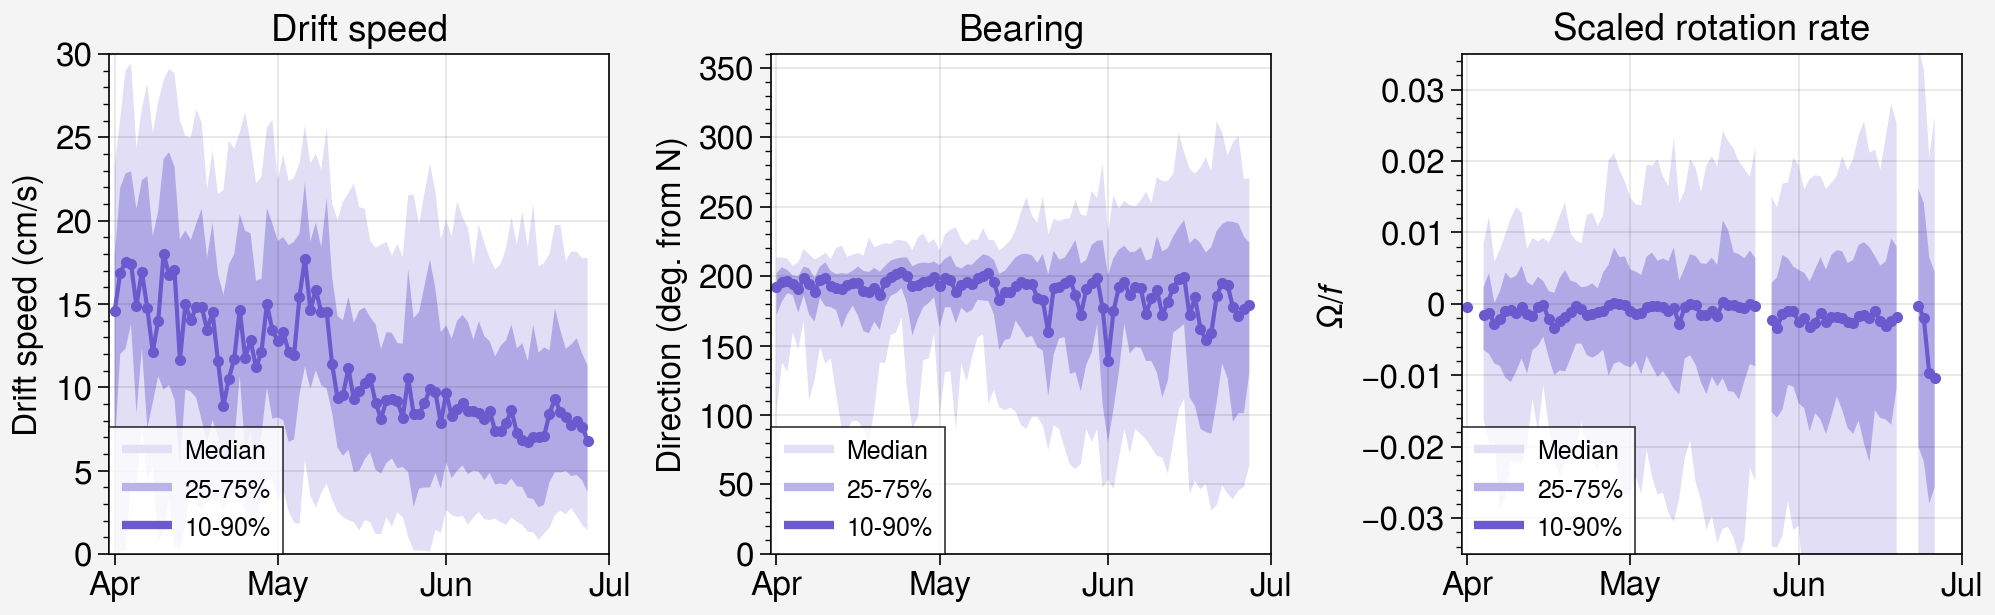

In [92]:
fig, axs = pplt.subplots(ncols=3, share=False)
idx = df_ift.speed.notnull()
df_ift['speed_cms'] = 100 * df_ift['speed']
df_ift['doy'] = df_ift.datetime.dt.dayofyear
ylims = {}
ylims['bearing'] = (0, 360)
ylims['speed_cms'] = (0, 30)
ylims['omega'] = (-0.035, 0.035)

for col, var in zip([0, 1, 2],
                          ['speed_cms', 'bearing', 'omega']):
    # shade data
    ax = axs[col]
    n = df_ift.loc[idx, [var, 'doy']].groupby('doy').count()
    med = df_ift.loc[idx, [var, 'doy']].groupby('doy').median().where(n > 150)
    p90 = df_ift.loc[idx, [var, 'doy']].groupby('doy').quantile(0.90).where(n > 150)
    p10 = df_ift.loc[idx, [var, 'doy']].groupby('doy').quantile(0.10).where(n > 150)
    p75 = df_ift.loc[idx, [var, 'doy']].groupby('doy').quantile(0.75).where(n > 150)
    p25 = df_ift.loc[idx, [var, 'doy']].groupby('doy').quantile(0.25).where(n > 150)
    ax.plot(med[var], fadedata=[p90[var], p10[var]],
            shadedata=[p75[var], p25[var]], marker='.', color='slateblue')
    ax.format(ylabel=var.replace('_', ' '),
              xlocator=dr.dayofyear, xlim=(91, pd.to_datetime('2000-07-01').dayofyear),
              xformatter=[d.strftime('%b') for d in dr],
              xlabel='', fontsize=12, ylim=ylims[var])

h = [ax.plot([],[], lw=3, ls='-', color=colors[m]) for m in [4, 5, 7]]
for ax in axs:
    ax.legend(h, ['Median', '25-75%', '10-90%'], ncols=1, loc='ll')


axs[0].format(ylabel='Drift speed (cm/s)', title='Drift speed')
axs[1].format(ylabel='Direction (deg. from N)', title='Bearing')
axs[2].format(title='Scaled rotation rate', ylabel='$\\Omega/f$')
fig.save('../figures/presentations/drift_speed_dist.pdf', dpi=300)

In [94]:
df_ift.columns

Index(['datetime', 'floe_id', 'longitude', 'latitude', 'x_stere', 'y_stere',
       'area', 'perimeter', 'axis_major_length', 'axis_minor_length',
       'solidity', 'circularity', 'nsidc_sic', 'lr_probability', 'zeta',
       'zeta_est', 'u', 'v', 'bearing', 'speed', 'area_km2', 'perimeter_km',
       'axis_major_length_km', 'axis_minor_length_km', 'edge_dist_km',
       'coast_dist_km', 'u_nsidc', 'v_nsidc', 'u5D_nsidc', 'v5D_nsidc',
       'u15D_nsidc', 'v15D_nsidc', 'u31D_nsidc', 'v31D_nsidc', 'area_adj_km2',
       'edge_bin', 'length_scale', 'length_bin', 'f_parameter', 'omega',
       'speed_cms', 'doy', 'L', 'qc_flag'],
      dtype='object')

<a list of 1 Line2D objects>

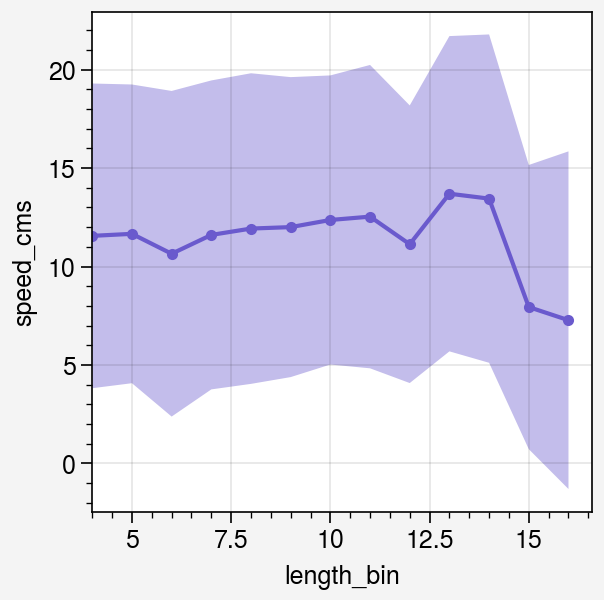

In [104]:
idx = df_ift.nsidc_sic.between(0, 0.85)
idx = df_ift.nsidc_sic > 0.85
df_binned = df_ift.loc[idx, ['length_bin', 'length_scale', 'speed_cms']].groupby('length_bin').mean()
df_binned['speed_cms_std'] = df_ift.loc[idx, ['length_bin', 'speed_cms']].groupby('length_bin').std()
df_binned['n'] = df_ift.loc[idx, ['length_bin', 'speed_cms']].groupby('length_bin').count()

fig, ax = pplt.subplots()
df = df_binned.where(df_binned.n > 100)
ax.plot(df['speed_cms'], shadedata=df['speed_cms_std'], color='slateblue', marker='.')

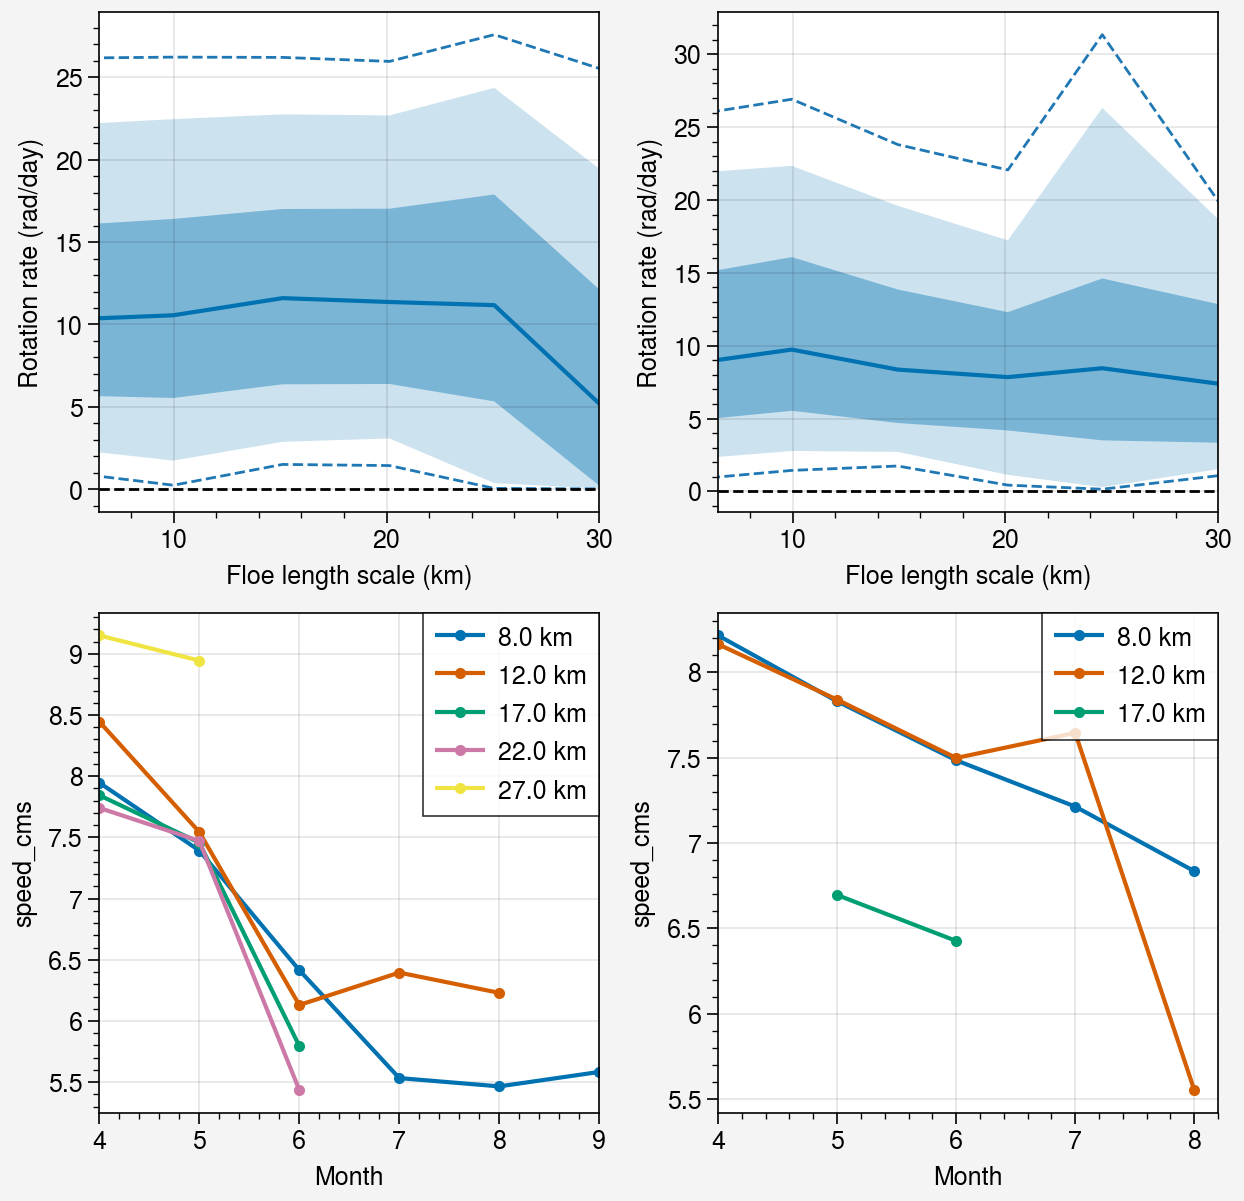

In [25]:
var = 'speed_cms'
df_ift['L'] = df_ift['area_adj_km2']**0.5
sic = df_ift['nsidc_sic']
df_ift.loc[sic > 1, 'nsidc_sic'] = np.nan
df_ift['speed_cms'] = 100 * np.sqrt(df_ift['u']**2 + df_ift['v']**2)
# Additional filter
# I think I added this into the prep script
speed = np.sqrt(df_ift.loc[:, 'u']**2 + df_ift.loc[:, 'v']**2)
mean_u = df_ift.loc[:, 'u'].mean()
mean_v = df_ift.loc[:, 'v'].mean()
z = np.sqrt((df_ift.u - mean_u)**2 + (df_ift.v - mean_v)**2)/np.std(speed)
df_ift['qc_flag'] = 0
df_ift.loc[np.abs(z) > 6, 'qc_flag'] = 1
df_filtered = df_ift.loc[df_ift.qc_flag==0]

df_filtered['l_bin'] = np.digitize(df_filtered['L'], bins=np.arange(0, 60, 5))
df_filtered['l_center'] = [pd.Series(np.arange(2.5, 63, 5), index=np.arange(1, 14))[x] for x in df_filtered['l_bin']]
subset = df_filtered.loc[(df_filtered.qc_flag == 0) & df_filtered.zeta.notnull()].copy()

subset['month'] = subset.datetime.dt.month
subset['year'] = subset.datetime.dt.year
subset['length_scale_km'] = np.sqrt(subset['area_km2'])

pack_subset = subset.loc[subset.nsidc_sic >= 0.85]
miz_subset = subset.loc[subset.nsidc_sic < 0.85]

pack_counts = pack_subset.groupby(['month', 'l_bin']).count()[var].reset_index().pivot_table(
    index='month', columns='l_bin', values=var)
pack_summary = pack_subset.loc[:, ['l_bin', var]].groupby('l_bin').quantile([0.05, 0.1, 0.25, 0.5, 0.75, 0.90, 0.95])
pack_summary.reset_index(inplace=True)
pack_summary.columns=['l_bin', 'quantile', var]
pack_summary = pack_summary.pivot_table(index='l_bin', columns='quantile', values=var)

x = pack_subset[['l_bin', 'length_scale_km']].groupby('l_bin').mean()
pack_summary.index = x.loc[pack_summary.index].values.squeeze()

miz_summary = miz_subset.loc[:, ['l_bin', var]].groupby('l_bin').quantile([0.05, 0.1, 0.25, 0.5, 0.75, 0.90, 0.95])
miz_summary.reset_index(inplace=True)
miz_summary.columns=['l_bin', 'quantile', var]
miz_summary = miz_summary.pivot_table(index='l_bin', columns='quantile', values=var)

x = miz_subset[['l_bin', 'length_scale_km']].groupby('l_bin').mean()
miz_summary.index = x.loc[miz_summary.index].values.squeeze()

fig, axs = pplt.subplots(ncols=2, nrows=2, share=False)
for data, ax in zip([pack_summary, miz_summary], axs[0,:]):
    ax.plot(data[0.05], ls='--', lw=1, color='tab:blue')
    ax.plot(data[0.95], ls='--', lw=1, color='tab:blue')
    
    ax.plot(data[0.5], shadedata=[data[0.25], data[0.75]],
            fadedata=[data[0.1], data[0.9]])
    ax.format(ylabel='Rotation rate (rad/day)', #ylim=(-1, 1),
              xlocator=np.arange(10, 31, 10), xlim=(6.5, 30),
              xlabel='Floe length scale (km)')
    ax.axhline(0, color='k', ls='--', lw=1)
for data, ax in zip([pack_subset, miz_subset], axs[1,:]):
    counts = data.groupby(['month', 'l_bin']).count()[var].reset_index().pivot_table(
    index='month', columns='l_bin', values=var)

    for bin_num in range(2, 9):
        L = data.loc[data.l_bin==bin_num, 'L'].mean()
        v = data.loc[data.l_bin==bin_num, ['month', var]].groupby('month').std()
        n = counts[bin_num]
        if sum(n > 100) > 1:
            ax.plot(v.where(n > 100), label=str(np.round(L, 0)) + ' km', marker='.')

    ax.legend(ncols=1, loc='ur')
    ax.format(ylabel=var, xlabel='Month')#, ylim=(0, 0.3))

In [ ]:
df_ift['year'] = df_ift.datetime.dt.year
var = 'speed'

In [ ]:
var = 'speed'
fig, axs = pplt.subplots(ncols=4)
for ax, month, month_name in zip(axs, [4, 5, 6, 7], ['April', 'May', 'June', 'July']):
    results = []
    for year, data in df_ift.loc[(df_ift.datetime.dt.month == month)].groupby('year'):
        idx = data.speed.notnull()
        med = data.loc[idx, var].median() #.where(n > 50)
        p90 = data.loc[idx, var].quantile(0.90) #.where(n > 50)
        p10 = data.loc[idx, var].quantile(0.10) #.where(n > 50)
        p75 = data.loc[idx, var].quantile(0.75) #.where(n > 50)
        p25 = data.loc[idx, var].quantile(0.25) #.where(n > 50)
        results.append([year, p10, p25, med, p75, p90])
    results = pd.DataFrame(results, columns=['year', 'p10', 'p25', 'med', 'p75', 'p90']).set_index('year')
    ax.plot(results['med'], shadedata=[results['p25'], results['p75']], fadedata=[results['p10'], results['p90']], marker='.')
    ax.format(title=month_name, xrotation=45, xlabel='', suptitle='Drift speed')

In [ ]:
df_ift['year'] = df_ift.datetime.dt.year

var = 'omega'
fig, axs = pplt.subplots(ncols=4)
for ax, month, month_name in zip(axs, [4, 5, 6, 7], ['April', 'May', 'June', 'July']):
    results = []
    for year, data in df_ift.loc[(df_ift.datetime.dt.month == month)].groupby('year'):
        idx = data[var].notnull()
        med = data.loc[idx, var].median() #.where(n > 50)
        p90 = data.loc[idx, var].quantile(0.90) #.where(n > 50)
        p10 = data.loc[idx, var].quantile(0.10) #.where(n > 50)
        p75 = data.loc[idx, var].quantile(0.75) #.where(n > 50)
        p25 = data.loc[idx, var].quantile(0.25) #.where(n > 50)
        results.append([year, p10, p25, med, p75, p90])
    results = pd.DataFrame(results, columns=['year', 'p10', 'p25', 'med', 'p75', 'p90']).set_index('year')
    ax.plot(results['med'], shadedata=[results['p25'], results['p75']], fadedata=[results['p10'], results['p90']], marker='.')
    ax.format(title=month_name, xrotation=45, xlabel='', suptitle='Drift speed')

In [ ]:

df_ift['L'] = df_ift['area_adj_km2']**0.5
df_ift['l_bin'] = np.digitize(df_ift['L'], bins=np.arange(0, 60, 5))
df_ift['l_center'] = [pd.Series(np.arange(2.5, 63, 5), index=np.arange(1, 14))[x] for x in df_ift['l_bin']]
df_ift.loc[:, ['l_bin', 'zeta']].groupby('l_bin').quantile([0.05, 0.1, 0.25, 0.5, 0.75, 0.90, 0.95])

# Estimates of the role of wind in the seasonal cycle

In [11]:

df_era = pd.read_csv('../data/ft_with_wind.csv')
df_era['datetime'] = pd.to_datetime(df_era['date'])
df_era.columns

Index(['Unnamed: 0', 'Unnamed: 1', 'date', 'floe_id', 'x', 'y', 'longitude',
       'latitude', 'u', 'v', 'bearing', 'speed', 'u_wind', 'v_wind',
       'wind_speed', 'wind_bearing', 'turning_angle', 'drift_speed_ratio',
       'datetime'],
      dtype='object')

In [14]:
u_est = 0.03 * (df_era['u_wind'] + 1j*df_era['v_wind']) * np.exp(-1j*np.deg2rad(24.5))
u = np.real(u_est)
v = np.imag(u_est)
err = np.sqrt((u - df_era['u'])**2 + (v - df_era['v'])**2)
df_era['err_wind_model'] = err

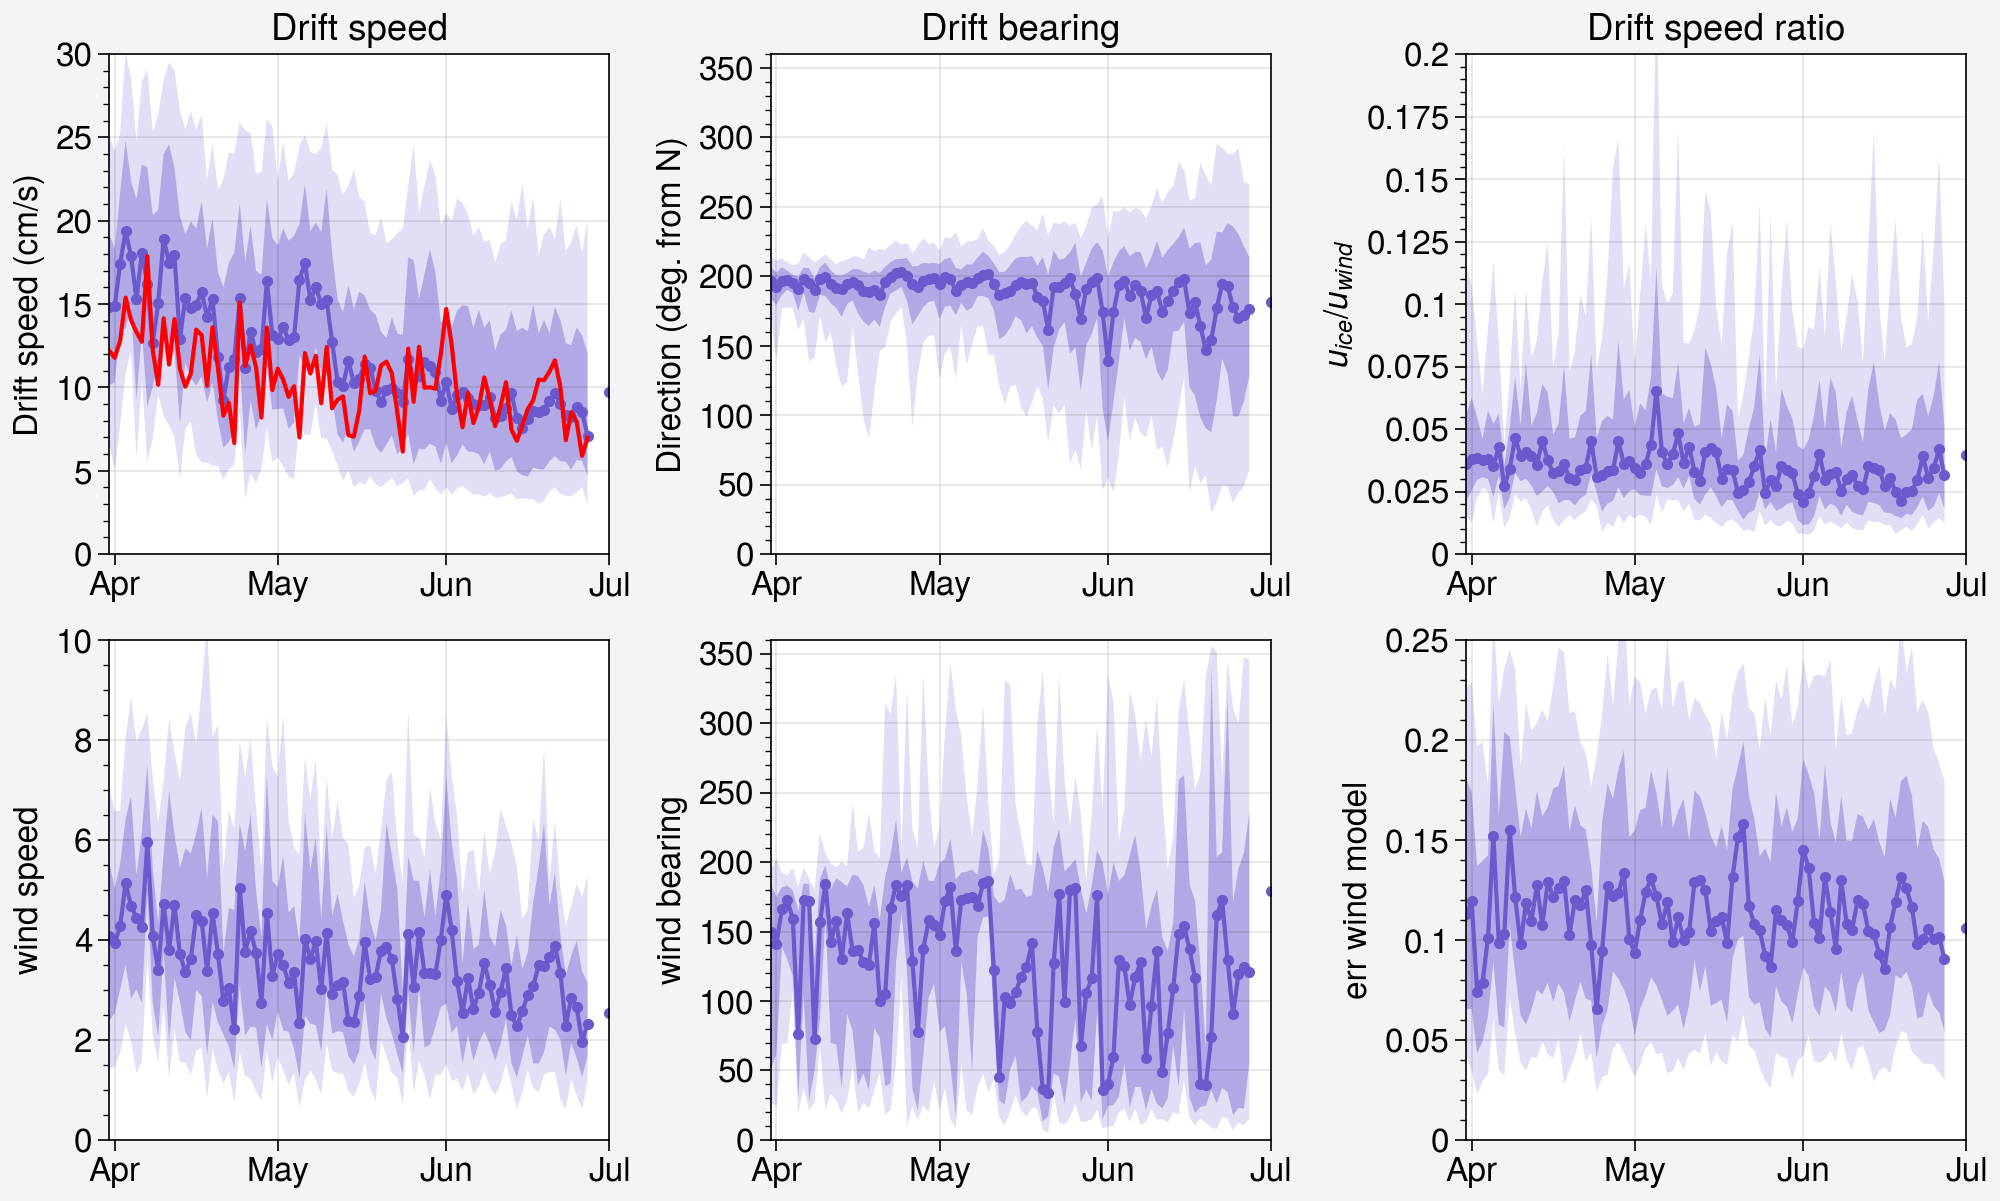

In [16]:
fig, axs = pplt.subplots(ncols=3, nrows=2, share=False)
idx = df_era.speed.notnull()
df_era['speed_cms'] = 100 * df_era['speed']
df_era['doy'] = df_era.datetime.dt.dayofyear
ylims = {}
ylims['bearing'] = (0, 360)
ylims['speed_cms'] = (0, 30)
ylims['drift_speed_ratio'] = (0, 0.2)
ylims['wind_speed'] = (0, 10)
ylims['wind_bearing'] = (0, 360)
ylims['err_wind_model'] = (0, 0.25)

for col, var in zip(range(6),
                          ['speed_cms', 'bearing', 'drift_speed_ratio',
                          'wind_speed', 'wind_bearing', 'err_wind_model']):
    # shade data
    ax = axs[col]
    n = df_era.loc[idx, [var, 'doy']].groupby('doy').count()
    med = df_era.loc[idx, [var, 'doy']].groupby('doy').median().where(n > 150)
    p90 = df_era.loc[idx, [var, 'doy']].groupby('doy').quantile(0.90).where(n > 150)
    p10 = df_era.loc[idx, [var, 'doy']].groupby('doy').quantile(0.10).where(n > 150)
    p75 = df_era.loc[idx, [var, 'doy']].groupby('doy').quantile(0.75).where(n > 150)
    p25 = df_era.loc[idx, [var, 'doy']].groupby('doy').quantile(0.25).where(n > 150)
    ax.plot(med[var], fadedata=[p90[var], p10[var]],
            shadedata=[p75[var], p25[var]], marker='.', color='slateblue')
    ax.format(ylabel=var.replace('_', ' '),
              xlocator=dr.dayofyear, xlim=(91, pd.to_datetime('2000-07-01').dayofyear),
              xformatter=[d.strftime('%b') for d in dr],
              xlabel='', fontsize=12, ylim=ylims[var])

# comparison with wind, given alpha of 0.03
var = 'wind_speed'
n = df_era.loc[idx, [var, 'doy']].groupby('doy').count()
med = df_era.loc[idx, [var, 'doy']].groupby('doy').median().where(n > 150)
axs[0].plot(med[var] * 3, color='r')

axs[0].format(ylabel='Drift speed (cm/s)', title='Drift speed')
axs[1].format(ylabel='Direction (deg. from N)', title='Drift bearing')
axs[2].format(title='Drift speed ratio', ylabel='$u_{ice}/u_{wind}$')
fig.save('../figures/presentations/drift_speed_dist_wind.pdf', dpi=300)

In [69]:

### Prepare histograms and binned statistics 
x = df_era.longitude
y = df_era.latitude
longrid = np.arange(-30, 15, 0.5)
latgrid = np.arange(65, 85, 0.25)
nmin = 20
lon_c = 0.5*(longrid[1:] + longrid[:-1])
lat_c = 0.5*(latgrid[1:] + latgrid[:-1])

# Estimate wind component
model_alpha = 0.02
model_theta = 20
U_est = model_alpha * np.exp(1j*np.deg2rad(model_theta))*(df_era['u_wind'] + 1j*df_era['v_wind'])
u_est = pd.Series(np.real(U_est), index=df_era.index)
v_est = pd.Series(np.imag(U_est), index=df_era.index)
df_era['u_est'] = u_est
df_era['v_est'] = v_est
df_era['u_res'] = df_era['u'] - df_era['u_est']
df_era['v_res'] = df_era['v'] - df_era['v_est']

# Variables:
# N, u_median, v_median, wind_speed, u_res, v_res
hist2d = np.histogram2d(df_era['longitude'],
               df_era['latitude'],
              bins=[longrid, latgrid])
df_hist = pd.DataFrame(hist2d[0], index=lon_c, columns=lat_c)

sel = df_era.wind_speed.notnull()
u_median, xedges, yedges, binnumber = stats.binned_statistic_2d(
    x[sel], y[sel], values=df_era.u[sel], statistic='median', 
    bins=[longrid, latgrid])
v_median, xedges, yedges, binnumber = stats.binned_statistic_2d(
    x[sel], y[sel], values=df_era.v[sel], statistic='median', 
    bins=[longrid, latgrid])
wind_speed, xedges, yedges, binnumber = stats.binned_statistic_2d(
    x[sel], y[sel], values=df_era.wind_speed[sel], statistic='median', 
    bins=[longrid, latgrid])
u_res, xedges, yedges, binnumber = stats.binned_statistic_2d(
    x[sel], y[sel], values=df_era.u_res[sel], statistic='median', 
    bins=[longrid, latgrid])
v_res, xedges, yedges, binnumber = stats.binned_statistic_2d(
    x[sel], y[sel], values=df_era.v_res[sel], statistic='median', 
    bins=[longrid, latgrid])
speed_mad, xedges, yedges, binnumber = stats.binned_statistic_2d(
    x[sel], y[sel], values=df_era.speed[sel], statistic=stats.median_abs_deviation, 
    bins=[longrid, latgrid])
speed, xedges, yedges, binnumber = stats.binned_statistic_2d(
    x[sel], y[sel], values=df_era.speed[sel], statistic='median', 
    bins=[longrid, latgrid])

u_median = pd.DataFrame(u_median, index=lon_c, columns=lat_c)
v_median = pd.DataFrame(v_median, index=lon_c, columns=lat_c)
u_res = pd.DataFrame(u_res, index=lon_c, columns=lat_c)
v_res = pd.DataFrame(v_res, index=lon_c, columns=lat_c)
speed_mad = pd.DataFrame(speed_mad, index=lon_c, columns=lat_c)
speed = pd.DataFrame(speed, index=lon_c, columns=lat_c)
wind_speed = pd.DataFrame(wind_speed, index=lon_c, columns=lat_c)

variables = {
    'Observation Counts': {'data': df_hist.where(df_hist > 0),
                           'vmin': 0,
                           'vmax': 200,
                           'clabel': 'N'},
    'Drift Speed': {'data': speed.where(df_hist > nmin) * 100,
                    'vmin': 0,
                    'vmax': 20,
                    'clabel': 'cm/s'},
    'Median Abs. Deviation': {'data': speed_mad.where(df_hist > nmin),
                 'vmin': 0,
                 'vmax': 0.2,
                 'clabel': 'm/s'},
    'Drift Velocity': {'data_u': u_median.where(df_hist > nmin),
                        'data_v': v_median.where(df_hist > nmin),
                        },
    'Wind Speed': {'data': wind_speed.where(df_hist > nmin),
                         'vmin': 0,
                         'vmax': 10,
                         'clabel': 'm/s'},
    'U Residual': {'data': u_res.where(df_hist > nmin),
                 'vmin': -0.15,
                 'vmax': 0.15,
                 'clabel': 'm/s'},
    'V Residual': {'data': v_res.where(df_hist > nmin),
                 'vmin': -0.15,
                 'vmax': 0.15,
                 'clabel': 'm/s'},
    'Residual Velocity': {'data_u': u_res.where(df_hist > nmin),
                           'data_v': v_res.where(df_hist > nmin),
                          }}


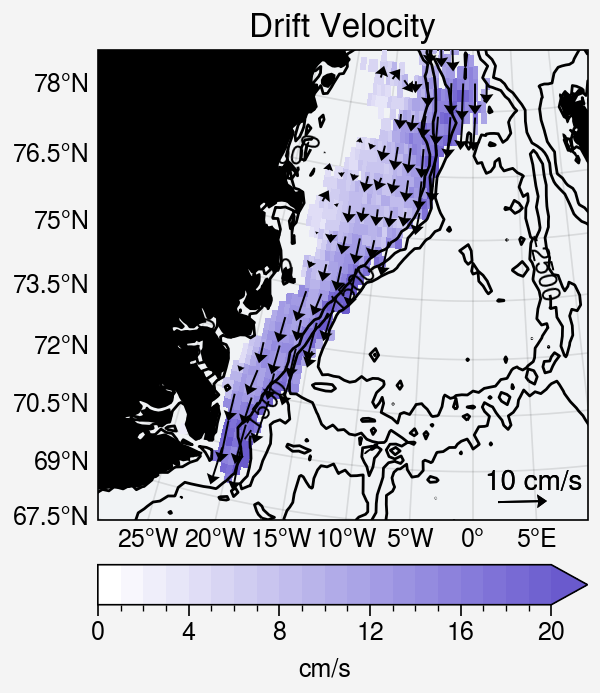

In [90]:
pplt.rc.reso = 'med'
import xarray as xr

### Load data
ds_depth = xr.open_dataset('/Users/dwatkin2/Documents/research/manuscripts/published/evidence_of_abrupt_changes/archive/data/interpolated_depth.nc')


fig, ax = pplt.subplots(proj='lcc', width=3, proj_kw={'lon_0': 0}, ncols=1, nrows=1, share=False)

ax.format(land=True, latlim=(69,80),
           lonlim=(-30,9), facecolor='gray1', landzorder=10, lonlabels=True)

ax.contour(ds_depth.longitude,
                ds_depth.latitude,
                ds_depth.z, levels=[-2500, -1500,  -500, 0],
           colors=['k', 'k', 'gray1'], ls='-', labels=True, zorder=5, lw=1)

for variable in ['Drift Speed', 'Drift Velocity']:
    if 'Velocity' not in variable:
        ex = 'max'
        cmap = 'slateblue'
        df = variables[variable]['data']
        ax.format(latlabels=True)
        c = ax.pcolormesh(lon_c, lat_c, df.T, zorder=4,
                          vmin=variables[variable]['vmin'],
                          vmax=variables[variable]['vmax'], N=20,
                          cmap=cmap, extend=ex)
        ax.colorbar(c, label=variables[variable]['clabel'], loc='b')
        ax.format(title=variable, titlesize=10)
        
    else:
        u = variables[variable]['data_u']
        v = variables[variable]['data_v']
        ax.quiver(lon_c[::3], lat_c[::3],
          u.T.loc[::3, ::3],
          v.T.loc[::3, ::3],
          zorder=10, scale=2, width=2/500, headwidth=7, headlength=5, color='k')
        ax.format(title=variable, titlesize=12)

# # ax.format(latlabels=True)
# for ax in [axs[0,-1], axs[1,-1]]:
    ax.quiver(2, 69.65, 0.1, 0,
          zorder=10, scale=1, width=2/500, headwidth=7, headlength=5, color='k')
    ax.text(1, 70, '10 cm/s', color='k', fontsize=10, transform=ccrs.PlateCarree())
fig.save('../figures/presentations/drift_map.pdf', dpi=300)

In [ ]:
fig, ax = pplt.subplots()
ax.plot(df_era['v'].values[0:100])
ax.plot(v[0:100])

In [ ]:
import scipy.stats as stats

In [ ]:
stats.binned_statistic_2d?

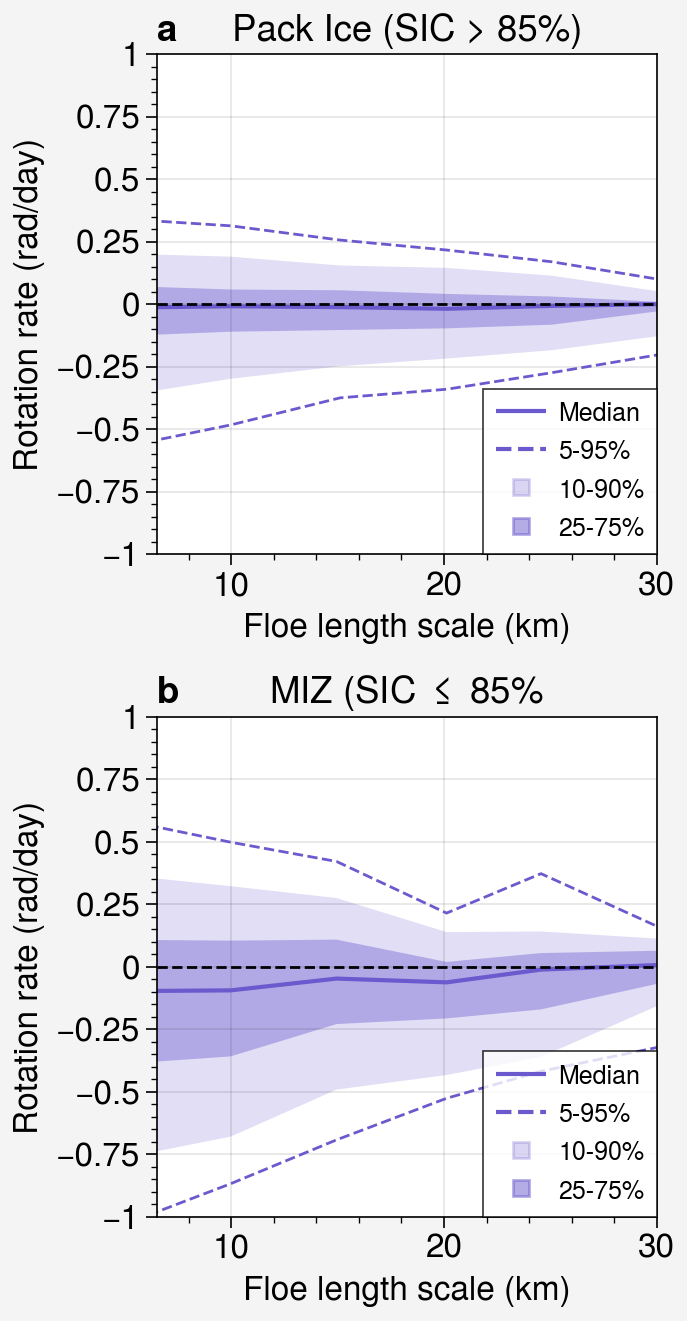

In [109]:
import ultraplot as pplt
import numpy as np
import pandas as pd

ift_loc = '../data/floe_tracker/ift_floe_trajectories.csv'
df_ift = pd.read_csv(ift_loc, index_col=0)
df_ift['datetime'] = pd.to_datetime(df_ift['datetime'].values)
df_ift['area_adj_km2'] = (np.sqrt(df_ift.area) + 8)**2*.25*.25 # 8 pixel shift and convert to km2

# edge_bins = np.arange(0, 800, 25)
# df_ift['edge_bin'] = np.digitize(df_ift.edge_dist_km, bins=edge_bins)


df_ift['L'] = df_ift['area_adj_km2']**0.5
sic = df_ift['nsidc_sic']
df_ift.loc[sic > 1, 'nsidc_sic'] = np.nan

# Additional filter
# I think I added this into the prep script
speed = np.sqrt(df_ift.loc[:, 'u']**2 + df_ift.loc[:, 'v']**2)
mean_u = df_ift.loc[:, 'u'].mean()
mean_v = df_ift.loc[:, 'v'].mean()

z = np.sqrt((df_ift.u - mean_u)**2 + (df_ift.v - mean_v)**2)/np.std(speed)
df_ift['qc_flag'] = 0
df_ift.loc[np.abs(z) > 6, 'qc_flag'] = 1
df_filtered = df_ift.loc[df_ift.qc_flag==0]

df_filtered['l_bin'] = np.digitize(df_filtered['L'], bins=np.arange(0, 60, 5))
df_filtered['l_center'] = [pd.Series(np.arange(2.5, 63, 5), index=np.arange(1, 14))[x] for x in df_filtered['l_bin']]
subset = df_filtered.loc[(df_filtered.qc_flag == 0) & df_filtered.zeta.notnull()].copy()

subset['month'] = subset.datetime.dt.month
subset['year'] = subset.datetime.dt.year
subset['length_scale_km'] = np.sqrt(subset['area_km2'])

pack_subset = subset.loc[subset.nsidc_sic >= 0.85]
miz_subset = subset.loc[subset.nsidc_sic < 0.85]

pack_counts = pack_subset.groupby(['month', 'l_bin']).count()['zeta'].reset_index().pivot_table(
    index='month', columns='l_bin', values='zeta')
pack_summary = pack_subset.loc[:, ['l_bin', 'zeta']].groupby('l_bin').quantile([0.05, 0.1, 0.25, 0.5, 0.75, 0.90, 0.95])
pack_summary.reset_index(inplace=True)
pack_summary.columns=['l_bin', 'quantile', 'zeta']
pack_summary = pack_summary.pivot_table(index='l_bin', columns='quantile', values='zeta')

x = pack_subset[['l_bin', 'length_scale_km']].groupby('l_bin').mean()
pack_summary.index = x.loc[pack_summary.index].values.squeeze()

miz_summary = miz_subset.loc[:, ['l_bin', 'zeta']].groupby('l_bin').quantile([0.05, 0.1, 0.25, 0.5, 0.75, 0.90, 0.95])
miz_summary.reset_index(inplace=True)
miz_summary.columns=['l_bin', 'quantile', 'zeta']
miz_summary = miz_summary.pivot_table(index='l_bin', columns='quantile', values='zeta')

x = miz_subset[['l_bin', 'length_scale_km']].groupby('l_bin').mean()
miz_summary.index = x.loc[miz_summary.index].values.squeeze()

fig, axs = pplt.subplots(ncols=1, nrows=2, share=False)
for data, ax in zip([pack_summary, miz_summary], axs):
    ax.plot(data[0.05], ls='--', lw=1, color='slateblue')
    ax.plot(data[0.95], ls='--', lw=1, color='slateblue')
    
    ax.plot(data[0.5], shadedata=[data[0.25], data[0.75]],
            fadedata=[data[0.1], data[0.9]], color='slateblue')
    ax.format(ylabel='Rotation rate (rad/day)', ylim=(-1, 1),
              xlocator=np.arange(10, 31, 10), xlim=(6.5, 30),
              xlabel='Floe length scale (km)')
    ax.axhline(0, color='k', ls='--', lw=1)

h = []
for alpha, ls, m in zip([1, 1, 0.25,  0.5], ['-', '--', '', ''], ['', '', 's', 's']):
    h.append(ax.plot([],[],color='slateblue', alpha=alpha, ls=ls, m=m))
axs[0].legend(h, ['Median',  '5-95%', '10-90%', '25-75%'], ncols=1, loc='lr')
axs[1].legend(h, ['Median',  '5-95%', '10-90%', '25-75%'], ncols=1, loc='lr')

axs[0].format(title='Pack Ice (SIC > 85%)', fontsize=12)
axs[1].format(title='MIZ (SIC $\\leq$ 85%', fontsize=12)
axs.format(abc=True)

for imtype in ['png', 'pdf']:
    fig.save('../figures/presentations/rotation_rate_variance.{im}'.format(im=imtype), dpi=300)